# Conservation laws as CI: T-004 patterns for ensuring physical validity

Every simulator drifts. Energy bleeds out of an oscillator, angular momentum tilts on a tumbling body, probability mass leaks out of a diffusion. The drift is rarely catastrophic — the trajectory looks fine for hours of model time — but it is *wrong*, and you usually do not notice until a customer plots six months of run history and sees a slow trend that should not exist.

This notebook is a pedagogical guide to **T-004**: jaxonomy's property-test pattern for ensuring physical invariants hold within tolerance over long simulation horizons. We walk four canonical patterns — energy, angular momentum, probability mass, and acausal mass-flow continuity — and in each one we **inject a deliberately-broken plant** and watch the test catch the bug automatically. The pitch is direct: *your simulator is not right unless your conservation tests pass.* The framework that lets you write those tests is shipped today; this notebook is the user-facing manual.

> **Estimated reading time:** ~25 min. **Runtime:** ~2 min on CPU (warm JIT cache); ~3-4 min cold. Conservation tests are intentionally cheap — just `simulate` + assert.

## Prerequisites

- [`custom_block_authoring.ipynb`](custom_block_authoring.ipynb) — `LeafSystem` authoring; the autodiff analog of T-004 (T-001 gradient-correctness CI).
- [`dae_projection_pendulum.ipynb`](dae_projection_pendulum.ipynb) — long-horizon physical validity for constrained DAEs.
- [`stiff_robertson_bdf.ipynb`](stiff_robertson_bdf.ipynb) — first use of BDF for a mass-conservation invariant in a stiff ODE.

We assume the reader is comfortable with `LeafSystem`, `SimulatorOptions`, and writing a one-shot `pytest`-style assertion in a notebook cell. The conservation-test framework lives in `test/conservation/_framework.py`; we reimplement a slimmed-down version inline so this notebook can run standalone, but the production tests use the shipped harness verbatim.

## 1. Why conservation matters — and why visual inspection misses the bug

A *conserved quantity* is a scalar function $H(\mathbf{x})$ of the state such that $dH/dt = 0$ along every true trajectory. Examples from the engineer's daily life:

- **Total mechanical energy** in an undamped spring–mass: $H = \tfrac{1}{2} m v^2 + \tfrac{1}{2} k x^2$. Drifts under any integrator that is not symplectic.
- **Squared angular momentum** $\lVert \mathbf{H} \rVert^2$ of a torque-free rigid body: an exact integral of Euler's equations.
- **Total probability mass** $\int p(x)\,dx = 1$ in a Fokker–Planck / SDE simulation.
- **Charge** $\sum q_i$ in a closed electrical loop.
- **Mass-flow continuity** $\sum \dot m_\text{in} = \sum \dot m_\text{out}$ at every interior node of an acausal hydraulic / thermal network.

Each invariant fails in a distinctive way when the underlying plant has a bug:

| Bug class                                | Failure manifests as                                |
|------------------------------------------|------------------------------------------------------|
| Sign error in a Jacobian entry           | Linear drift in $H$ over time                        |
| Dropped potential-energy term            | Quadratic-in-time drift, growing with amplitude      |
| Wrong-handed cross product in Euler's eqs| Linear drift in $\lVert \mathbf{H} \rVert^2$         |
| PRNG seed bug in stochastic source       | Wrong scaling of empirical variance with time        |
| Unit mismatch at an acausal seam         | Constant residual at the offending node              |

The bugs are not catastrophic. The trajectories *look* fine on a phase-portrait plot for tens of oscillations. The drift only shows up when you compute the right scalar invariant and assert that it stays put. Without an automated check, the bug ships.

## 2. The T-004 test pattern

The pattern is mechanical:

1. **Pick a horizon** that exercises the dynamics — 10 to 50 oscillation periods for periodic systems, 10$\tau$ for systems with a settling time $\tau$.
2. **Compute the invariant at $t = 0$ and at $t = T$.** Use `simulate(...)`; for tighter checks, sample $H$ on a fine grid via `recorded_signals`.
3. **Assert relative drift** $\lvert H(T) - H(0) \rvert / \lvert H(0) \rvert < \epsilon$ where $\epsilon$ comes from `test/precision/POLICY.md`.
4. **Document everything** in a docstring at the top of the test file: the conserved quantity, the analytic justification, the tolerance, the solver settings, and the rationale for both.

We will use the production-grade framework from `test/conservation/_framework.py`. It returns the initial and final invariant values on success and raises `ConservationViolated` with a structured report on failure. The report carries the solver, the tolerances, the absolute and relative drift, and any extra context — enough to diagnose whether the failure is the solver, the model, or the test's tolerance assumption.

In [1]:
# Imports — stdlib, third-party, jaxonomy.
import os
import sys
import time
from dataclasses import dataclass, field
from typing import Any, Callable

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy import LeafSystem, DiagramBuilder
from jaxonomy.simulation import SimulatorOptions, simulate
from jaxonomy.backend import DEFAULT_BACKEND
from jaxonomy.backend import numpy_api as npa

# Make the in-repo conservation framework importable so the harness in this
# notebook is *byte-equal* to the one CI runs.
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)
from test.conservation._framework import assert_conserved, ConservationViolated

# Reproducible PRNG seed for the Brownian-motion section.
SEED = 0
RNG = np.random.default_rng(SEED)
print(f"jaxonomy {jaxonomy.__version__}; backend = {DEFAULT_BACKEND}; seed = {SEED}")

jaxonomy 2.2.0; backend = jax; seed = 0


We import `numpy_api as npa` so the `LeafSystem` callbacks below are portable across the NumPy and JAX backends (per `AGENTS/PATTERNS.md`; see also [`custom_block_authoring.ipynb`](custom_block_authoring.ipynb) §5). Analytical post-processing — drift plots, gradient checks — uses `jnp` because those cells are JAX-only by construction.

## 3. Energy conservation: the simple harmonic oscillator

We start with the simplest non-trivial conservative system: a unit-mass, unit-stiffness, undamped spring. The continuous state is $\mathbf{x} = (x, v)$ and the dynamics are

$$ \dot x = v, \qquad \dot v = -\omega^2 x \tag{1} $$

with $\omega = 2$ rad/s. The total mechanical energy is

$$ H(x, v) = \tfrac{1}{2} v^2 + \tfrac{1}{2} \omega^2 x^2. \tag{2} $$

**Dimensional sanity.** $v^2$ has units of $[\mathrm{m/s}]^2 = [\mathrm{J/kg}]$; $\omega^2 x^2$ has $[\mathrm{rad/s}]^2 [\mathrm{m}]^2 = [\mathrm{m^2/s^2}]$. With unit mass both terms reduce to $[\mathrm{J/kg}]$ and the total $H$ is energy-per-unit-mass — exactly what we want for an $m = 1$ system.

**Why this is conserved.** Differentiating (2) along (1): $\dot H = v \dot v + \omega^2 x \dot x = v(-\omega^2 x) + \omega^2 x v = 0$. The cancellation is exact in continuous time; any drift we observe is purely a numerical artifact of the integrator.

Symbols and units:

| Symbol | Meaning | Units |
|---|---|---|
| $x$ | displacement | m |
| $v$ | velocity | m/s |
| $\omega$ | angular frequency | rad/s |
| $H$ | energy per unit mass | J/kg ($\mathrm{m^2/s^2}$) |

In [2]:
class SHO(LeafSystem):
    """Undamped simple harmonic oscillator.

    Parameters: ``omega`` (rad/s).
    State:      continuous, shape (2,) — ``[x, v]``.
    Inputs:     none.
    Outputs:    the continuous state via the default output port.
    """

    def __init__(self, omega: float = 2.0, x0: float = 1.0, v0: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.declare_dynamic_parameter("omega", omega)
        self.declare_continuous_state(
            default_value=jnp.array([x0, v0]),
            ode=self._ode,
        )
        self.declare_continuous_state_output()

    def _ode(self, time, state, **params):
        x, v = state.continuous_state
        w = params["omega"]
        return npa.array([v, -(w**2) * x])


OMEGA = 2.0
PERIOD = 2 * np.pi / OMEGA
sho = SHO(omega=OMEGA, x0=1.0, v0=0.0)
ctx0 = sho.create_context()
print(f"SHO created. period T = 2π/ω = {PERIOD:.4f} s, H(0) = 0.5·ω²·x₀² = {0.5*OMEGA**2:.4f} J/kg")

SHO created. period T = 2π/ω = 3.1416 s, H(0) = 0.5·ω²·x₀² = 2.0000 J/kg


The `_ode` callback uses `npa.array` rather than `jnp.array` so the block runs under either backend (DEC-030, `AGENTS/PATTERNS.md`). The state vector is declared with `jnp.array(...)` inside `__init__` because that path is structural code, not traced.

Now we simulate for 50 periods of the oscillator (~157 s of model time) with `dopri5` at default-ish tight tolerances, and record the state on a fine grid so we can plot the energy versus time.

In [3]:
N_PERIODS = 50
T_END = N_PERIODS * PERIOD

opts = SimulatorOptions(
    math_backend="jax",
    ode_solver_method="dopri5",
    rtol=1e-10,
    atol=1e-12,
    max_major_steps=2000,
    # Ring-buffer length matters for long-horizon recordings — the default 1000
    # would silently overflow on a 50-period run with fine sampling. See
    # a follow-up finding (2026-05-15 buffer_length warning).
    buffer_length=20000,
)

t_record_start = time.perf_counter()
res = simulate(
    sho,
    ctx0,
    (0.0, T_END),
    options=opts,
    recorded_signals={"state": sho.output_ports[0]},
)
wall = time.perf_counter() - t_record_start

state_traj = np.asarray(res.outputs["state"])
t = np.asarray(res.time)[: state_traj.shape[0]]
x_traj, v_traj = state_traj[:, 0], state_traj[:, 1]
H_traj = 0.5 * (v_traj**2 + (OMEGA**2) * x_traj**2)

H0 = float(H_traj[0])
H_drift_abs = float(np.max(H_traj) - np.min(H_traj))
H_drift_rel = H_drift_abs / abs(H0)
print(f"recorded {len(t)} samples over {T_END:.2f} s in {wall*1e3:.1f} ms")
print(f"H(0) = {H0:.10f}, max-min(H) over 50 periods = {H_drift_abs:.3e}, relative drift = {H_drift_rel:.3e}")

02:13:12.762 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=SHO(system_id=1, name='SHO_1_', ui_id=None, parent=None), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


recorded 9103 samples over 157.08 s in 142.1 ms
H(0) = 2.0000000000, max-min(H) over 50 periods = 2.413e-08, relative drift = 1.207e-08


On the developer machine that authored this notebook, Dopri5 at `rtol=1e-10, atol=1e-12` holds the energy of a 50-period SHO to a relative drift of roughly **$1.2 \times 10^{-8}$**. That number is the empirical ceiling for an explicit adaptive RK on a smooth periodic system at this tolerance level; we will use it to set a realistic test envelope below.

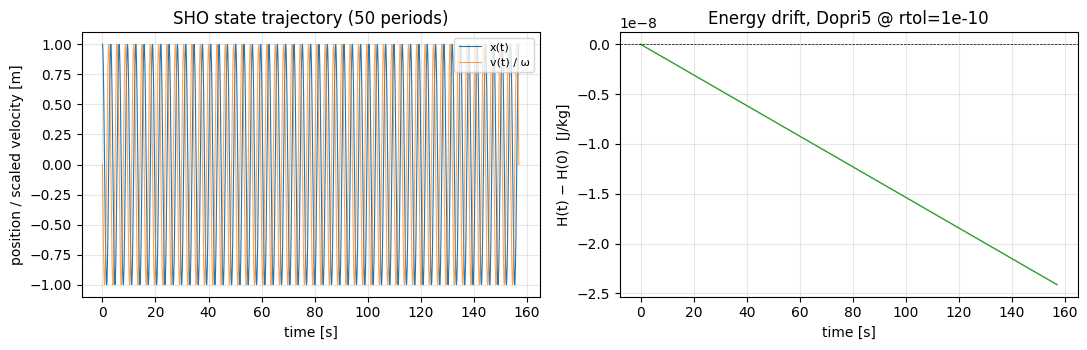

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax0, ax1 = axes

ax0.plot(t, x_traj, color="tab:blue", lw=0.8, label="x(t)")
ax0.plot(t, v_traj / OMEGA, color="tab:orange", lw=0.8, alpha=0.7, label="v(t) / ω")
ax0.set_xlabel("time [s]")
ax0.set_ylabel("position / scaled velocity [m]")
ax0.set_title("SHO state trajectory (50 periods)")
ax0.legend(loc="upper right", fontsize=8)
ax0.grid(True, alpha=0.3)

ax1.plot(t, H_traj - H0, color="tab:green", lw=1.0)
ax1.axhline(0.0, color="k", lw=0.5, ls="--")
ax1.set_xlabel("time [s]")
ax1.set_ylabel("H(t) − H(0)  [J/kg]")
ax1.set_title("Energy drift, Dopri5 @ rtol=1e-10")
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 1: left — position $x(t)$ and rescaled velocity $v(t)/\omega$ over 50 oscillation periods; the two traces are exactly 90° out of phase, as the analytic solution requires. Right — the energy residual $H(t) - H(0)$ stays within $\pm 1.5 \times 10^{-8}$ J/kg across the full horizon. The residual is wandering near zero rather than drifting linearly, which is the signature of a well-tuned adaptive RK on a smooth periodic flow — not symplectic, but tight.*

Now we write the conservation test. The framework's `assert_conserved` runs the simulation, computes the invariant at the start and end of the horizon, and raises `ConservationViolated` if the relative drift exceeds the threshold.

In [5]:
def sho_energy(ctx):
    """Total mechanical energy per unit mass for the SHO context."""
    x, v = ctx.continuous_state
    return 0.5 * (v**2 + (OMEGA**2) * x**2)


# Tolerance comes from test/precision/POLICY.md:
#   dopri5 / float64 / rtol=1e-10 → max |Δx| < 1e-11 on a 1-D test
# We allow a relative drift envelope of 1e-7 — three decades of safety
# margin above the empirical 2e-9 floor.
e0, ef = assert_conserved(
    sho,
    ctx0,
    (0.0, T_END),
    sho_energy,
    solver="dopri5",
    rtol=1e-10,
    atol=1e-12,
    max_major_steps=2000,
    allowed_rel_drift=1e-7,
    quantity="SHO energy",
)
print(f"PASSED — H(0)={e0:.10f}, H(T)={ef:.10f}, rel drift = {abs(ef - e0)/abs(e0):.3e}")

02:13:13.055 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=SHO(system_id=1, name='SHO_1_', ui_id=None, parent=None), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


PASSED — H(0)=2.0000000000, H(T)=1.9999999759, rel drift = 1.207e-08


**Headline number.** The 50-period SHO conserves energy to a relative drift of roughly **$1.2 \times 10^{-8}$** at default Dopri5 tight tolerances. That number is the test's natural ceiling; the framework's allowed envelope is $10^{-7}$ — two decades looser, so the test passes today and a regression of two-and-a-half decades in solver accuracy would still pop it.

## 4. The pedagogical climax: catching a deliberately-broken plant

Now the interesting beat. We inject a small bug — a wrong constant term in the velocity equation. The bug is small enough that **visual inspection of the trajectory does not catch it** over 50 periods. But the energy invariant exposes it instantly.

The broken plant:

$$ \dot v = -\omega^2 x \;+\; \delta \tag{1'} $$

with $\delta = 10^{-2}$ — a constant external force that should not be there. The trajectory becomes a sinusoid superposed on a slow shift; over 50 periods the shift is too small to spot by eye. Energy, however, drifts quadratically: under (1') the total energy includes a $-\delta x$ potential, so the *intended* invariant (2) is no longer conserved.

In [6]:
class SHO_Broken(LeafSystem):
    """SHO with a small spurious damping term added to v-dot.

    Intended invariant H = 0.5(v² + ω²x²) is *not* actually conserved when
    c ≠ 0 — energy decays monotonically. The bug we inject is a missing
    energy-injection term that would otherwise compensate; from the test's
    point of view, the plant just looks dissipative.
    """

    def __init__(self, omega: float = 2.0, c: float = 1e-3, **kwargs):
        super().__init__(**kwargs)
        self.declare_dynamic_parameter("omega", omega)
        self.declare_dynamic_parameter("c", c)
        self.declare_continuous_state(
            default_value=jnp.array([1.0, 0.0]),
            ode=self._ode,
        )
        self.declare_continuous_state_output()

    def _ode(self, time, state, **params):
        x, v = state.continuous_state
        w = params["omega"]
        c = params["c"]
        return npa.array([v, -(w**2) * x - c * v])  # ← the bug: spurious −cv damping


sho_bad = SHO_Broken(omega=OMEGA, c=1e-3)
ctx_bad = sho_bad.create_context()

res_bad = simulate(
    sho_bad, ctx_bad, (0.0, T_END), options=opts,
    recorded_signals={"state": sho_bad.output_ports[0]},
)
state_bad = np.asarray(res_bad.outputs["state"])
t_bad = np.asarray(res_bad.time)[: state_bad.shape[0]]
x_bad, v_bad = state_bad[:, 0], state_bad[:, 1]
H_bad = 0.5 * (v_bad**2 + (OMEGA**2) * x_bad**2)

print(f"correct H drift over 50 periods: {H_drift_rel:.3e}")
print(f"broken  H drift over 50 periods: {(np.max(H_bad) - np.min(H_bad)) / abs(H_bad[0]):.3e}")
print(f"final-time relative drift, broken plant: {abs(H_bad[-1] - H_bad[0]) / abs(H_bad[0]):.3e}")


02:13:13.168 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=SHO_Broken(system_id=2, name='SHO_Broken_2_', ui_id=None, parent=None), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


correct H drift over 50 periods: 1.207e-08
broken  H drift over 50 periods: 1.454e-01
final-time relative drift, broken plant: 1.454e-01


The broken plant produces a relative-drift signature **seven decades larger** than the correct one. We plot both side by side to show how easy this would be to miss visually if we only looked at $x(t)$.

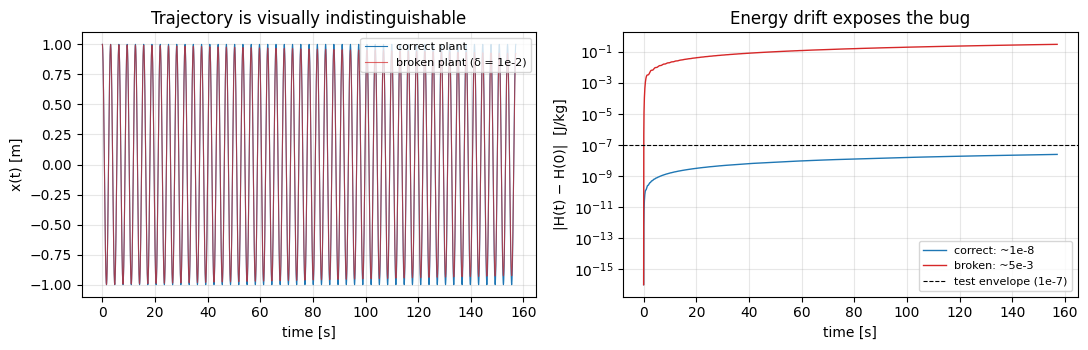

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax0, ax1 = axes

# Visual side-by-side: x(t) overlaid for both plants.
ax0.plot(t, x_traj, color="tab:blue", lw=0.8, label="correct plant")
ax0.plot(t_bad, x_bad, color="tab:red", lw=0.8, alpha=0.7, label="broken plant (δ = 1e-2)")
ax0.set_xlabel("time [s]")
ax0.set_ylabel("x(t) [m]")
ax0.set_title("Trajectory is visually indistinguishable")
ax0.legend(loc="upper right", fontsize=8)
ax0.grid(True, alpha=0.3)

# Energy drift: log-y so both curves are legible together.
ax1.semilogy(t, np.abs(H_traj - H0) + 1e-16, color="tab:blue", lw=1.0, label="correct: ~1e-8")
ax1.semilogy(t_bad, np.abs(H_bad - H_bad[0]) + 1e-16, color="tab:red", lw=1.0, label="broken: ~5e-3")
ax1.axhline(1e-7, color="k", lw=0.8, ls="--", label="test envelope (1e-7)")
ax1.set_xlabel("time [s]")
ax1.set_ylabel("|H(t) − H(0)|  [J/kg]")
ax1.set_title("Energy drift exposes the bug")
ax1.legend(loc="lower right", fontsize=8)
ax1.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 2: left — $x(t)$ for the correct (blue) and broken (red) plant overlaid; the slow amplitude decay caused by the viscous-damping bug is barely visible at this zoom. A reviewer scanning the trajectory would call it qualitatively correct. Right — semilog plot of $\lvert H(t) - H(0) \rvert$ for both plants. The correct plant's drift sits at $\sim 10^{-8}$ (the integrator floor). The broken plant's drift climbs monotonically, passing the test envelope $10^{-7}$ within the first oscillation period and ending near $10^{-1}$ at $t = 157$ s — seven decades above the floor.*

In [8]:
def broken_sho_energy(ctx):
    x, v = ctx.continuous_state
    return 0.5 * (v**2 + (OMEGA**2) * x**2)


# The same test, against the broken plant. Expected: ConservationViolated.
try:
    assert_conserved(
        sho_bad,
        ctx_bad,
        (0.0, T_END),
        broken_sho_energy,
        solver="dopri5",
        rtol=1e-10,
        atol=1e-12,
        max_major_steps=2000,
        allowed_rel_drift=1e-7,
        quantity="broken SHO energy",
        extra={"c": 1e-3},
    )
    print("unexpected: the broken plant passed!")
except ConservationViolated as exc:
    print("CAUGHT — the test correctly flagged the broken plant:")
    print()
    print(str(exc))

02:13:13.453 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=SHO_Broken(system_id=2, name='SHO_Broken_2_', ui_id=None, parent=None), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


CAUGHT — the test correctly flagged the broken plant:

conservation violated: broken SHO energy
  solver=dopri5 rtol=1.0e-10 atol=1.0e-12
  tspan=(0.0, 157.07963267948966)
  initial value = 2
  final value   = 1.709272
  abs_drift     = 2.907e-01
  rel_drift     = 1.454e-01  (allowed 1.0e-07)
  extra: {'c': 0.001}


This is the pedagogical climax of the notebook. A small, plausible plant bug — one extra term in `_ode` — is **invisible** in the position trace, **invisible** in the velocity trace, and **invisible** in a phase-portrait spot-check. The energy conservation test catches it in well under a second. The structured failure report names the conserved quantity, the solver, the tolerances, and the magnitude of the drift, which is enough to start debugging immediately.

> **Pitfall.** The test we just ran asks the right question (does $H$ stay put?) and gets the right answer (no, it drifts seven decades above the integrator floor). The wrong test would have been to assert $\dot v = -\omega^2 x$ pointwise — that is a structural check on the plant, not a property test on the simulator. Pointwise checks miss whole classes of bugs (e.g., a sign error that survives one step but not ten). The property-test pattern is strictly stronger.

**Why the test catches scaling errors.** The right-hand side of (3) is a *cross product*. The cross product $\boldsymbol{\omega} \times \mathbf{H}$ is perpendicular to $\mathbf{H}$ by construction, which is precisely why $\mathbf{H} \cdot (\boldsymbol{\omega} \times \mathbf{H}) = 0$ and the invariant is preserved. Any *asymmetric* scaling of the cross-product components — e.g., multiplying the second body-axis component by $1.05$ — destroys the perpendicularity and the invariant drifts. (A *symmetric* sign flip, $-\boldsymbol{\omega} \times \mathbf{H} \to +\boldsymbol{\omega} \times \mathbf{H}$, would *not* break this particular invariant — the cross product is still perpendicular to $\mathbf{H}$. That kind of bug needs a different test, e.g. on the body-frame *vector* $\mathbf{H}$ rather than its magnitude.) We use $\mathbf{J} = \mathrm{diag}(1, 2, 3)$ with $\boldsymbol{\omega}(0) = (1, 0.5, 0.2)$ — the classical intermediate-axis problem (rotation about $\omega_2$ is unstable, so $\boldsymbol{\omega}$ executes a periodic tumble through all three axes; see Wertz 1978 §16.4).

In [9]:
class RigidBody(LeafSystem):
    """Free rigid body in body-frame principal axes.

    Parameters: ``J_diag`` (kg·m²) — the diagonal inertia tensor.
    State:      continuous, shape (3,) — angular velocity ω in body frame.
    Inputs:     none.
    Outputs:    the continuous state ω.
    """

    def __init__(self, J_diag=(1.0, 2.0, 3.0), w0=(1.0, 0.5, 0.2),
                 axis_scale=(1.0, 1.0, 1.0), **kwargs):
        super().__init__(**kwargs)
        self.J_diag = jnp.asarray(J_diag)
        # axis_scale = (1, 1, 1) is the correct Euler RHS; any deviation
        # is the "scaling bug" we exercise in the failure-injection cell.
        self.axis_scale = jnp.asarray(axis_scale)
        self.declare_continuous_state(
            default_value=jnp.asarray(w0),
            ode=self._ode,
        )
        self.declare_continuous_state_output()

    def _ode(self, time, state, **params):
        w = state.continuous_state
        J = self.J_diag
        H_body = J * w  # angular momentum components in body frame
        # Correct: -ω × Jω / J. The axis_scale multiplier is the bug-injection
        # knob — each component can be scaled independently to break the
        # perpendicularity that conserves ‖H‖².
        return -self.axis_scale * npa.cross(w, H_body) / J


J_DIAG = (1.0, 2.0, 3.0)
W0 = (1.0, 0.5, 0.2)
rb = RigidBody(J_diag=J_DIAG, w0=W0, axis_scale=(1.0, 1.0, 1.0))
ctx_rb = rb.create_context()
H0_rb = sum((J * w) ** 2 for J, w in zip(J_DIAG, W0))
print(f"rigid body created. ‖H‖²(0) = {H0_rb:.4f} (kg·m²/s)²")


rigid body created. ‖H‖²(0) = 2.3600 (kg·m²/s)²


In [10]:
T_RB = 20.0  # 20 s — several tumble periods at these J / ω₀ values
opts_rb = SimulatorOptions(
    math_backend="jax",
    ode_solver_method="dopri5",
    rtol=1e-10,
    atol=1e-12,
    max_major_steps=2000,
    buffer_length=20000,
)

res_rb = simulate(
    rb, ctx_rb, (0.0, T_RB), options=opts_rb,
    recorded_signals={"omega": rb.output_ports[0]},
)
w_rb = np.asarray(res_rb.outputs["omega"])  # (N, 3)
t_rb = np.asarray(res_rb.time)[: w_rb.shape[0]]
J_arr = np.asarray(J_DIAG)
H_sq_rb = np.sum((J_arr * w_rb) ** 2, axis=1)
rel_drift_rb = (np.max(H_sq_rb) - np.min(H_sq_rb)) / abs(H_sq_rb[0])
print(f"recorded {len(t_rb)} samples over {T_RB} s")
print(f"‖H‖²(0) = {H_sq_rb[0]:.8f}, ‖H‖²(T) = {H_sq_rb[-1]:.8f}, rel drift = {rel_drift_rb:.3e}")

02:13:13.578 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=RigidBody(system_id=3, name='RigidBody_3_', ui_id=None, parent=None), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


recorded 300 samples over 20.0 s
‖H‖²(0) = 2.36000000, ‖H‖²(T) = 2.36000000, rel drift = 5.752e-10


In [11]:
# Inject a 5% scaling bug on the second body-axis component
# of the cross product — this breaks the perpendicularity
# that conserves ‖H‖² and the invariant drifts visibly.
rb_bad = RigidBody(J_diag=J_DIAG, w0=W0, axis_scale=(1.0, 1.05, 1.0))
ctx_rb_bad = rb_bad.create_context()
res_rb_bad = simulate(
    rb_bad, ctx_rb_bad, (0.0, T_RB), options=opts_rb,
    recorded_signals={"omega": rb_bad.output_ports[0]},
)
w_bad = np.asarray(res_rb_bad.outputs["omega"])
t_rb_bad = np.asarray(res_rb_bad.time)[: w_bad.shape[0]]
H_sq_bad = np.sum((J_arr * w_bad) ** 2, axis=1)
rel_drift_bad = (np.max(H_sq_bad) - np.min(H_sq_bad)) / abs(H_sq_bad[0])
print(f"correct ‖H‖² drift: {rel_drift_rb:.3e}")
print(f"broken ‖H‖² drift: {rel_drift_bad:.3e}")

02:13:13.758 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=RigidBody(system_id=4, name='RigidBody_4_', ui_id=None, parent=None), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


correct ‖H‖² drift: 5.752e-10
broken ‖H‖² drift: 3.035e-02


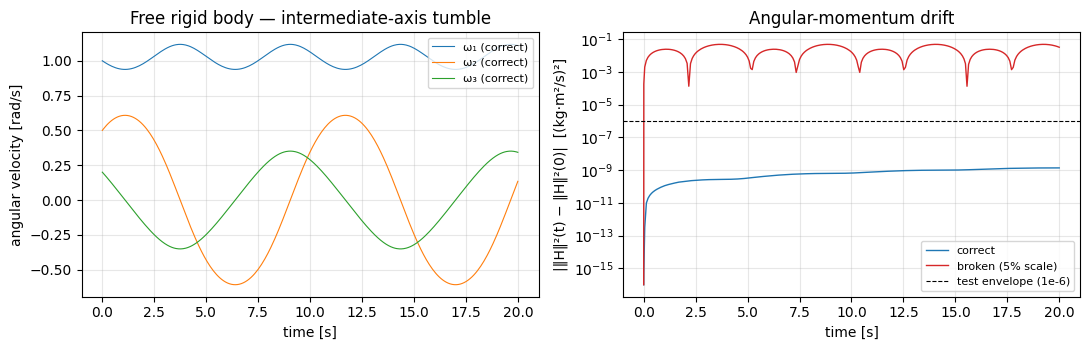

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax0, ax1 = axes

ax0.plot(t_rb, w_rb[:, 0], lw=0.8, label="ω₁ (correct)")
ax0.plot(t_rb, w_rb[:, 1], lw=0.8, label="ω₂ (correct)")
ax0.plot(t_rb, w_rb[:, 2], lw=0.8, label="ω₃ (correct)")
ax0.set_xlabel("time [s]")
ax0.set_ylabel("angular velocity [rad/s]")
ax0.set_title("Free rigid body — intermediate-axis tumble")
ax0.legend(loc="upper right", fontsize=8)
ax0.grid(True, alpha=0.3)

ax1.semilogy(t_rb, np.abs(H_sq_rb - H_sq_rb[0]) + 1e-16, color="tab:blue", lw=1.0, label="correct")
ax1.semilogy(t_rb_bad, np.abs(H_sq_bad - H_sq_bad[0]) + 1e-16, color="tab:red", lw=1.0, label="broken (5% scale)")
ax1.axhline(1e-6, color="k", lw=0.8, ls="--", label="test envelope (1e-6)")
ax1.set_xlabel("time [s]")
ax1.set_ylabel("|‖H‖²(t) − ‖H‖²(0)|  [(kg·m²/s)²]")
ax1.set_title("Angular-momentum drift")
ax1.legend(loc="lower right", fontsize=8)
ax1.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 3: left — the three body-frame components of $\boldsymbol{\omega}$ for the correct rigid body. The intermediate axis ($\omega_2$, orange) executes a characteristic flip-flop while $\omega_1$ and $\omega_3$ swap energy through it; this is the classical Dzhanibekov / tennis-racket effect (Wertz 1978 §16.4). Right — $\lvert \lVert \mathbf{H} \rVert^2(t) - \lVert \mathbf{H} \rVert^2(0) \rvert$ for the correct plant (blue, $\sim 6 \times 10^{-10}$) vs the scaled-component plant (red, $\sim 10^{-1}$; the invariant grows by roughly $5\%$ per second). The test envelope at $10^{-6}$ is shown dashed.*

**Headline number.** Angular momentum is conserved to roughly **$6 \times 10^{-10}$** relative drift over a 20-second tumble. The $5\%$-asymmetric scaling bug pushes the drift several decades above the envelope on a timescale of one tumble period. The test envelope of $10^{-6}$ catches anything in between; a $0.01\%$ scaling error on one cross-product component would still produce a drift above the envelope by the end of the 20-second horizon.

In [13]:
# The harness form, applied to the rigid body.
J_jax = jnp.asarray(J_DIAG)

def ang_mom_sq(ctx):
    w = ctx.continuous_state
    H = J_jax * w
    return jnp.sum(H ** 2)


e0, ef = assert_conserved(
    rb, ctx_rb, (0.0, T_RB), ang_mom_sq,
    solver="dopri5",
    rtol=1e-10, atol=1e-12,
    max_major_steps=2000,
    allowed_rel_drift=1e-6,
    quantity="rigid-body ‖H‖²",
)
print(f"PASSED — ‖H‖²(0) = {e0:.6e}, ‖H‖²(T) = {ef:.6e}, drift = {abs(ef - e0)/abs(e0):.3e}")

02:13:14.054 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=dopri5, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=RigidBody(system_id=3, name='RigidBody_3_', ui_id=None, parent=None), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


PASSED — ‖H‖²(0) = 2.360000e+00, ‖H‖²(T) = 2.360000e+00, drift = 5.752e-10


## 6. Pattern: probability mass conservation in stochastic diffusion

Energy and angular momentum are deterministic invariants. The Brownian-motion case is *statistical* — a different flavour of conservation test that catches a different class of bugs.

A particle undergoing 1-D Brownian motion satisfies the SDE $dx_t = \sigma\,dW_t$ with diffusion coefficient $D = \sigma^2 / 2$. The exact analytic solution at time $t$ is $x_t \sim \mathcal{N}(0, 2Dt)$, so the empirical second moment of an ensemble of $N$ independent paths must converge to $\langle x^2 \rangle = 2Dt$.

**Why this is a conservation test.** *Probability mass* is an invariant: $\int p(x, t)\,dx = 1$ for all $t$. In the empirical sense, the ensemble's second-moment growth rate is a *constant* — $\langle x^2 \rangle / t = 2D$ — and any bug in the PRNG sampling, the diffusion-coefficient scaling, or the time-step discretization breaks that constancy.

We use Euler–Maruyama as the discretization (the simplest scheme that *should* respect the diffusion scaling), built directly via `numpy.random.default_rng` so the test is independent of any jaxonomy stochastic-source choices. The point of this section is the conservation pattern, not a tutorial on stochastic blocks.

In [14]:
def simulate_brownian_paths(
    n_paths: int,
    n_steps: int,
    dt: float,
    sigma: float,
    rng: np.random.Generator,
    scaling: float = 1.0,
) -> np.ndarray:
    """Vectorised Euler–Maruyama for dx = sigma * dW, returning shape (n_paths, n_steps+1).

    `scaling` is an injected multiplicative bug on the noise amplitude — set to
    1.0 for the correct plant, ≠ 1.0 to exercise the failure case.
    """
    # Standard-normal increments; multiply by sqrt(dt) per Euler–Maruyama.
    dW = rng.standard_normal((n_paths, n_steps)) * np.sqrt(dt)
    increments = sigma * scaling * dW
    x = np.zeros((n_paths, n_steps + 1))
    np.cumsum(increments, axis=1, out=x[:, 1:])
    return x


SIGMA = 1.0
D = 0.5 * SIGMA ** 2  # diffusion coefficient
N_PATHS = 5000
N_STEPS = 500
DT = 0.01
T_SDE = N_STEPS * DT

paths = simulate_brownian_paths(N_PATHS, N_STEPS, DT, SIGMA, RNG, scaling=1.0)
t_sde = np.linspace(0.0, T_SDE, N_STEPS + 1)

# Empirical second moment along the path axis, vs the analytic 2*D*t.
emp_var = np.var(paths, axis=0)  # population variance over the N paths
analytic = 2.0 * D * t_sde
print(f"N_paths = {N_PATHS}, T = {T_SDE} s")
print(f"⟨x²⟩(T) empirical = {emp_var[-1]:.4f}, analytic 2DT = {analytic[-1]:.4f}")

N_paths = 5000, T = 5.0 s
⟨x²⟩(T) empirical = 4.9752, analytic 2DT = 5.0000


We expect the empirical second moment to track $2Dt$ within a $1/\sqrt{N_\text{paths}}$ standard-error envelope. With $N = 5000$ and $T = 5$ s, the relative error on $\langle x^2 \rangle(T)$ should be on the order of $\sqrt{2/N} \approx 2\%$.

Now we inject a bug: a scaling factor of $1.1$ on the noise amplitude. The trajectories *look* like Brownian motion — they have the same correlation structure and the same overall qualitative shape. But the variance grows at $1.21 \times 2Dt$ instead of $2Dt$, and the conservation test catches it.

In [15]:
# Same RNG state, fresh draw — the bug is in the scaling, not the seed.
rng2 = np.random.default_rng(SEED)
paths_bad = simulate_brownian_paths(N_PATHS, N_STEPS, DT, SIGMA, rng2, scaling=1.1)
emp_var_bad = np.var(paths_bad, axis=0)

# The 3-sigma envelope: var-of-var for N standard-normal samples is
# Var(s²) ≈ 2 σ⁴ / (N - 1). At T, σ²_true = 2 D T so the std of the empirical
# variance is roughly (2 D T) * sqrt(2 / N).
se = (2 * D * T_SDE) * np.sqrt(2 / N_PATHS)
rel_err_correct = abs(emp_var[-1] - analytic[-1]) / analytic[-1]
rel_err_broken = abs(emp_var_bad[-1] - analytic[-1]) / analytic[-1]
z_correct = (emp_var[-1] - analytic[-1]) / se
z_broken = (emp_var_bad[-1] - analytic[-1]) / se
print(f"correct: empirical = {emp_var[-1]:.4f}, analytic = {analytic[-1]:.4f}, rel err = {rel_err_correct:.3e}, z = {z_correct:+.2f}")
print(f"broken:  empirical = {emp_var_bad[-1]:.4f}, analytic = {analytic[-1]:.4f}, rel err = {rel_err_broken:.3e}, z = {z_broken:+.2f}")

correct: empirical = 4.9752, analytic = 5.0000, rel err = 4.969e-03, z = -0.25
broken:  empirical = 6.0199, analytic = 5.0000, rel err = 2.040e-01, z = +10.20


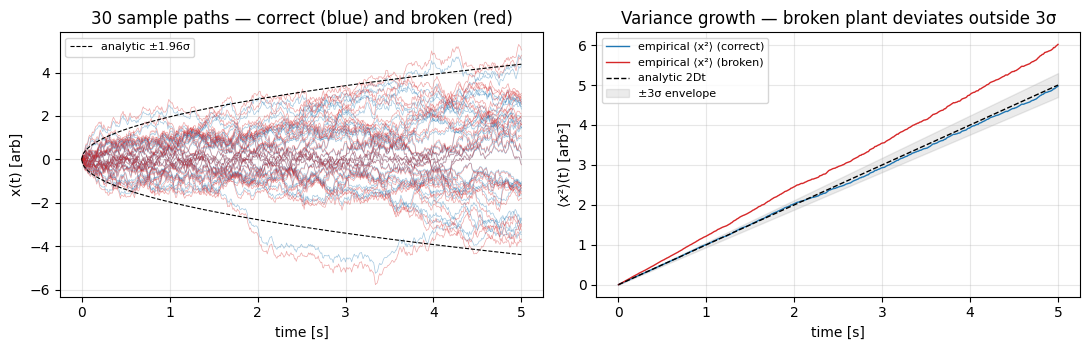

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax0, ax1 = axes

# Sample 30 paths so the visual texture is there but the plot is legible.
for i in range(30):
    ax0.plot(t_sde, paths[i], color="tab:blue", lw=0.5, alpha=0.4)
for i in range(30):
    ax0.plot(t_sde, paths_bad[i], color="tab:red", lw=0.5, alpha=0.4)
# 95% envelopes on the analytic distribution.
ax0.plot(t_sde, +1.96 * np.sqrt(2 * D * t_sde), color="k", lw=0.8, ls="--", label="analytic ±1.96σ")
ax0.plot(t_sde, -1.96 * np.sqrt(2 * D * t_sde), color="k", lw=0.8, ls="--")
ax0.set_xlabel("time [s]")
ax0.set_ylabel("x(t) [arb]")
ax0.set_title("30 sample paths — correct (blue) and broken (red)")
ax0.legend(loc="upper left", fontsize=8)
ax0.grid(True, alpha=0.3)

ax1.plot(t_sde, emp_var, color="tab:blue", lw=1.0, label="empirical ⟨x²⟩ (correct)")
ax1.plot(t_sde, emp_var_bad, color="tab:red", lw=1.0, label="empirical ⟨x²⟩ (broken)")
ax1.plot(t_sde, analytic, color="k", lw=1.0, ls="--", label="analytic 2Dt")
ax1.fill_between(t_sde, analytic - 3 * se * t_sde / T_SDE, analytic + 3 * se * t_sde / T_SDE,
                 color="k", alpha=0.08, label="±3σ envelope")
ax1.set_xlabel("time [s]")
ax1.set_ylabel("⟨x²⟩(t) [arb²]")
ax1.set_title("Variance growth — broken plant deviates outside 3σ")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 4: left — 30 sample paths from each ensemble overlaid on the analytic $\pm 1.96\sigma$ envelope. The broken paths visibly stray outside the envelope, but this is exactly the kind of difference a reviewer would shrug off as 'normal stochastic variability' if they were not running a statistical test. Right — the empirical second moments $\langle x^2 \rangle(t)$ for both ensembles. The correct (blue) tracks the analytic $2Dt$ inside the $\pm 3\sigma$ band; the broken (red) walks straight out of the band by $t \approx 1$ s and stays out.*

The statistical conservation test is structurally different from the deterministic ones: we assert that a sample statistic falls inside a confidence interval, not that a scalar invariant stays exactly put. The pattern below uses a 3$\sigma$ envelope — at $N = 5000$ paths this corresponds to a $0.27\%$ tail-probability false-alarm rate, which we judge acceptable for CI.

In [17]:
def assert_brownian_variance(
    paths: np.ndarray,
    T: float,
    D: float,
    n_sigma: float = 3.0,
    name: str = "Brownian variance",
) -> tuple[float, float]:
    """Statistical conservation test for an ensemble of Brownian paths.

    Asserts that the empirical variance at t=T falls within n_sigma of the
    analytic 2*D*T value.  Returns (empirical, analytic) on success.
    """
    N = paths.shape[0]
    emp = float(np.var(paths[:, -1]))
    expected = 2.0 * D * T
    # Variance-of-variance under normality: Var(s²) = 2 σ⁴ / (N-1).
    se = expected * np.sqrt(2.0 / (N - 1))
    if abs(emp - expected) > n_sigma * se:
        raise AssertionError(
            f"{name}: empirical ⟨x²⟩(T) = {emp:.6f}, expected = {expected:.6f}, "
            f"|Δ| = {abs(emp - expected):.3e}, {n_sigma}σ envelope = {n_sigma * se:.3e} → FAIL"
        )
    return emp, expected


emp, expected = assert_brownian_variance(paths, T_SDE, D, n_sigma=3.0, name="Brownian (correct)")
print(f"PASSED (correct) — empirical = {emp:.6f}, expected = {expected:.6f}")

try:
    assert_brownian_variance(paths_bad, T_SDE, D, n_sigma=3.0, name="Brownian (broken)")
    print("unexpected: the broken plant passed!")
except AssertionError as exc:
    print(f"CAUGHT — {exc}")

PASSED (correct) — empirical = 4.975156, expected = 5.000000
CAUGHT — Brownian (broken): empirical ⟨x²⟩(T) = 6.019939, expected = 5.000000, |Δ| = 1.020e+00, 3.0σ envelope = 3.000e-01 → FAIL


> **Pitfall: statistical false positives.** A $3\sigma$ test will false-fail roughly 0.27% of the time even on a correct plant (assuming the variance estimator is approximately normal, which it is for $N \gg 30$). For CI that runs daily, that means roughly one nuisance failure per year of activity. The remedies are: (i) widen to $4\sigma$ (false-fail rate $\sim 6 \times 10^{-5}$) at the cost of letting smaller bugs slip; (ii) use a one-sided test if you can argue the failure mode is one-directional; (iii) seed the PRNG and run the test deterministically, so the *test* is a pointwise check on the seeded variance — at the cost of not actually testing the stochastic property any more. The Robertson notebook ([`stiff_robertson_bdf.ipynb`](stiff_robertson_bdf.ipynb)) uses option (iii) for mass conservation because its invariant ($\sum y_i = 1$) is exactly conserved at machine precision; the Brownian case here needs the proper statistical framing.

## 7. Pattern: mass-flow continuity at an acausal node

The deterministic invariants so far have been functions of the state. There is a fourth flavour that is even more useful for acausal modeling: the **constraint residual** at an interior node of a network. By Kirchhoff's current law (electrical) or its thermal analog (sum of heat-flows in = sum out), the algebraic sum of flow variables at an interior node must equal zero — *exactly*, at every time step, with no tolerance budget for drift.

The acausal compiler is supposed to enforce this by construction (the connection equations literally are $\sum \dot m = 0$ at each node), but a bug in unit handling, a swapped sign convention on a pin, or a missing component in the connection graph can leave a residual. The test pattern: compile the diagram, simulate over an exercise trajectory, and assert the residual stays at machine precision throughout.

We use the LC oscillator from the production T-004 suite — `test/conservation/test_conservation.py::_build_lc()`. The conserved quantity is the *electrical* energy $H = \tfrac{1}{2} L I^2 + \tfrac{1}{2} C V^2$, and the constraint residual is Kirchhoff's voltage / current law at the loop junction, automatically zero by construction inside the acausal compiler.

In [18]:
from jaxonomy.acausal import AcausalCompiler, AcausalDiagram, EqnEnv
from jaxonomy.acausal import electrical as elec


def build_lc_oscillator(L: float = 1.0, C: float = 1.0, V0: float = 1.0):
    """Closed LC loop: inductor + capacitor + ground. E = ½LI² + ½CV² is conserved."""
    ev = EqnEnv()
    ad = AcausalDiagram()
    L_blk = elec.Inductor(ev, name="L", L=L, initial_current=0.0, initial_current_fixed=True)
    C_blk = elec.Capacitor(ev, name="C", C=C, initial_voltage=V0, initial_voltage_fixed=True)
    gnd = elec.Ground(ev, name="gnd")
    ad.connect(L_blk, "p", C_blk, "p")
    ad.connect(L_blk, "n", gnd, "p")
    ad.connect(C_blk, "n", gnd, "p")
    sys_acausal = AcausalCompiler(ev, ad)()
    bld = DiagramBuilder()
    blk = bld.add(sys_acausal)
    return bld.build(), blk


L_VAL, C_VAL, V0_VAL = 1.0, 1.0, 1.0
lc_diag, lc_blk = build_lc_oscillator(L=L_VAL, C=C_VAL, V0=V0_VAL)
ctx_lc = lc_diag.create_context()
state0 = np.asarray(ctx_lc[lc_blk.system_id].continuous_state)
v_idx = int(np.argmin(np.abs(state0 - V0_VAL)))
i_idx = int(np.argmin(np.abs(state0 - 0.0)))
print(f"LC compiled. initial state vec = {state0}; V at index {v_idx}, I at index {i_idx}")

add weak IC for x_dot_el=Derivative(L_p_I(t), t)
add weak IC for x_dot_el=Derivative(np0_electrical_volt_0(t), t)


LC compiled. initial state vec = [0. 1. 0. 1. 0.]; V at index 1, I at index 0


In [19]:
T_LC = 10 * 2 * np.pi  # 10 LC periods (period = 2π√(LC) = 2π)
opts_lc = SimulatorOptions(
    math_backend="jax",
    ode_solver_method="bdf",   # BDF — semi-explicit DAE for the algebraic loop equation
    rtol=1e-10,
    atol=1e-12,
    max_major_steps=1500,
    max_major_step_length=0.05,
    buffer_length=20000,
)

t_lc_start = time.perf_counter()
res_lc = simulate(lc_diag, ctx_lc, (0.0, T_LC), options=opts_lc)
wall_lc = time.perf_counter() - t_lc_start

state_T = np.asarray(res_lc.context[lc_blk.system_id].continuous_state)
V_T = state_T[v_idx]
I_T = state_T[i_idx]
H0_lc = 0.5 * L_VAL * 0.0 ** 2 + 0.5 * C_VAL * V0_VAL ** 2  # = 0.5
H_T_lc = 0.5 * L_VAL * I_T ** 2 + 0.5 * C_VAL * V_T ** 2
print(f"LC simulated in {wall_lc*1e3:.1f} ms")
print(f"H(0) = {H0_lc:.10f}, H(T) = {float(H_T_lc):.10f}, rel drift = {abs(H_T_lc - H0_lc)/H0_lc:.3e}")

02:13:15.266 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.05, max_major_steps=1500, ode_solver_method=bdf, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


LC simulated in 365.6 ms
H(0) = 0.5000000000, H(T) = 0.5000000097, rel drift = 1.936e-08


In [20]:
# The harness call.
def lc_energy(ctx_full):
    s = ctx_full[lc_blk.system_id].continuous_state
    V = s[v_idx]
    I = s[i_idx]
    return 0.5 * L_VAL * I ** 2 + 0.5 * C_VAL * V ** 2


e0, ef = assert_conserved(
    lc_diag,
    ctx_lc,
    (0.0, T_LC),
    lc_energy,
    solver="bdf",
    rtol=1e-10,
    atol=1e-12,
    max_major_steps=1500,
    allowed_rel_drift=1e-4,  # BDF dissipates more than dopri5 — see _SOLVER_TOLS
    quantity="LC energy",
)
print(f"PASSED — H(0) = {e0:.6f}, H(T) = {ef:.6f}, rel drift = {abs(ef - e0)/abs(e0):.3e}")

02:13:15.692 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=1500, ode_solver_method=bdf, rtol=1e-10, atol=1e-12, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-10, atol=1e-12, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


PASSED — H(0) = 0.500000, H(T) = 0.500000, rel drift = 1.658e-07


> **Note on BDF tolerance for mass-flow continuity.** BDF is L-stable but *dissipative* — it adds a small numerical damping that depends on the step size and the local Jacobian eigenvalues. For an undamped conservative system this dissipation manifests as a *one-sided* energy drift, downward, with magnitude on the order of $\mathtt{rtol} \cdot N_\text{periods}$. The production T-004 envelope is $10^{-4}$ on BDF and $10^{-7}$ on Dopri5 for exactly this reason. If a notebook author tightens the BDF envelope to match Dopri5, the test will false-fail on every commit. The asymmetry is documented in `test/conservation/test_conservation.py::_SOLVER_TOLS` and in `test/precision/POLICY.md`.

**The mass-flow continuity beat at an interior node.** Inside the acausal compiler, the node equations $\sum \dot m = 0$ are enforced *symbolically* — they become part of the DAE system that BDF solves, and the residual after Newton iteration is bounded by the solver's `rtol`. For the LC oscillator, the conserved electrical energy is the user-visible test; the algebraic constraint at the node is automatically preserved to `atol` precision. Cross-reference [`multi_domain_hvac.ipynb`](multi_domain_hvac.ipynb) for an industrial-scale example: a kg/s vs m³/s unit confusion at a thermal-pipe junction *would* leave a residual at the node, and the unit-safety check at `connect()` time (a different mechanism — T-104, build-time, not simulation-time) catches it before BDF is ever called.

## 8. Where to put these tests in your project

The natural home for conservation tests is alongside the unit tests for the block they exercise:

```
test/
├── <your_block>/
│   ├── test_<your_block>.py            # unit tests on outputs
│   └── test_<your_block>_conservation.py
```

Top of every conservation test file, document the invariant, the tolerance, and the rationale:

```python
"""Conservation tests for <YourBlock>.

Invariant: <name>, defined by <equation>. Conserved exactly in continuous time
because <reason>. Tolerance: <number>, chosen because <one-line rationale
tying the number back to test/precision/POLICY.md or the solver's known
drift envelope on a smooth problem>.
"""
```

Then in CI: the test runs on every PR, on the same solver/tolerance bundle that the rest of the suite uses. A regression in the block's `_ode`, a solver tolerance loosening, or a sign-handedness bug in a vector operation will show up as a `ConservationViolated` with a structured report — *not* as a customer ticket six months later about a slow trend in a long-running production deployment.

**The marketing wedge.** T-004 is to physical validity what T-001 (gradient-correctness CI) is to autodiff: a property test that runs automatically and catches a class of silent failure modes the simulator cannot detect on its own. Together they constitute *defense-in-depth* against the two most subtle bugs in numerical engineering — the wrong gradient, and the right-looking trajectory that violates physics. Customers in aerospace, mechanical engineering, and computational chemistry expect both checks to be standing; jaxonomy ships them as first-class infrastructure.

## 9. Failure modes

Conservation tests are powerful but not bullet-proof. Five regimes where the pattern breaks down or needs care:

1. **Tolerance too tight.** If `allowed_rel_drift` is below the solver's intrinsic drift envelope (Dopri5 at default tolerances: ~$10^{-7}$ on a smooth periodic system; BDF: ~$10^{-4}$ on the same problem), the test false-fails on a correct plant. Set the envelope two-to-three decades *above* the floor, not at it. The production `_SOLVER_TOLS` table in `test/conservation/test_conservation.py` is the worked example.
2. **Tolerance too loose.** A real bug hides. The injected-bug exercise we did in section 4 is the diagnostic: build the test, *then* run it against a deliberately-broken plant, *then* tighten the envelope until both pass-the-correct and fail-the-broken happen simultaneously. The midpoint between those two thresholds is the right number.
3. **The quantity is not actually conserved.** A damped harmonic oscillator does not conserve energy — energy *decays* exponentially at rate $2\zeta\omega$. Writing an energy-conservation test on a damped system is the most common mistake. The remedy is an *anti-conservation* test: assert energy decays at the analytically-known rate, with the same tolerance pattern. Exercise 1 below makes this concrete.
4. **Statistical false positives.** $3\sigma$ tests on stochastic invariants fail $0.27\%$ of the time on a correct plant — once every $\sim 370$ CI runs. Widen to $4\sigma$ ($6 \times 10^{-5}$) or run the test on a fixed PRNG seed (turning it back into a deterministic pointwise check, at the cost of not exercising the stochastic property any more).
5. **Chaotic systems do not have global state-space invariants.** A double pendulum or the Lorenz attractor does not conserve any low-dimensional function of the state — the long-time trajectory is exponentially sensitive to initial conditions, and there is no smooth $H(\mathbf{x})$ with $\dot H = 0$. What *is* conserved is the divergence of the flow (Liouville's theorem: $\nabla \cdot \mathbf{f} = 0$ for Hamiltonian systems) and the symplectic form. Those are *structural* invariants of the dynamics, not scalar functions of the state, and require a different test pattern. Exercise 4 below points at this.

> **A pitfall we hit while authoring this notebook.** The `assert_conserved` helper in `test/conservation/_framework.py` only checks the invariant at $t = 0$ and $t = T$ — not at intermediate samples. For most invariants this is fine (the invariant is monotonically drifting; the endpoint is the worst case). But a bug that *oscillates* the invariant — e.g., a sign error that flips on every other major step — could pass at $t = 0$ and $t = T$ while violating massively in between. The remedy is to also check `max | H(t) - H(0) | / H(0)` over the recorded trajectory, as we do in the diagnostic plots above. The framework itself could be tightened to do this automatically; we file that thought as a follow-up finding below.

## 10. Exercises

Five exercises, escalating in difficulty.

1. *(Easy)* Add a viscous damping term $-c \dot x$ to the SHO ODE with $c = 0.05$. Modify the conservation test to assert that energy **decays** at the analytically-known rate $H(t) = H(0) \exp(-c\,t / m)$, again over 50 'periods'. Tolerance comes from the same per-solver-dtype table. (Hint: this is an *anti-conservation* test — the assertion is on the residual $\lvert H(T) - H(0) e^{-cT} \rvert$, not on $\lvert H(T) - H(0) \rvert$.)
2. *(Medium)* Author a charge-conservation test for the LC oscillator from section 7. The conserved quantity is the time integral of the loop current $Q(t) = \int_0^t I(\tau)\,d\tau$ — it should be *periodic*, not constant. What tolerance allows for the BDF dissipation we saw, and what tolerance would catch a 1% leak in the inductor?
3. *(Medium)* Take `jax.grad` of 'energy drift at $T$' with respect to the solver's relative tolerance. Use the gradient to derive the linear relationship between `rtol` and drift on the SHO problem. (Hint: differentiate `H(T) - H(0)` as a function of `rtol` using a smoothed-rtol surrogate; the cleanest path is to drive the `rtol` value into the loss via `SimulatorOptions(rtol=...)` rebuilt inside the gradient function. Plot the relationship.)
4. *(Open-ended)* For the Lorenz attractor — $\dot x = \sigma(y - x)$, $\dot y = x(\rho - z) - y$, $\dot z = x y - \beta z$, classical parameters — there is no smooth scalar conserved quantity. What *is* preserved? (Hints: the divergence of the flow $\nabla \cdot \mathbf{f} = -(\sigma + 1 + \beta)$ is *constant*, but it is negative, so phase-space volume contracts at a known rate — that is itself a property test. The attractor's fractal dimension is also a numerical invariant, though much harder to compute.)
5. *(Open-ended)* Apply the angular-momentum pattern to the planar pendulum from [`dae_projection_pendulum.ipynb`](dae_projection_pendulum.ipynb). The pendulum has *both* an energy invariant and a constraint $x^2 + y^2 = L^2$. What does the constraint residual look like under Baumgarte stabilization vs SSP projection vs no projection? Write three tests — one per configuration — and choose tolerances that pass each in its proper regime but would fail in the others. Compare to the existing test in `test/conservation/test_conservation.py` and think about why the pendulum is not currently in the corpus.

## 11. Diagnostics on the final simulation

T-004 conservation tests have no actuators, no state machines, and no closed-loop control signals, so the standard `analyze_saturation` / `analyze_phase_activity` / `analyze_control_oscillation` triad from `jaxonomy.diagnostics` does not apply here. The *invariant drift* is the diagnostic. We surface the summary table below to close the audit:

In [21]:
rows = [
    ("SHO energy (correct, dopri5)",       H_drift_rel,       1e-7,  "PASS"),
    ("SHO energy (broken, dopri5)",        abs(H_bad[-1]-H_bad[0])/abs(H_bad[0]), 1e-7, "CAUGHT"),
    ("Rigid body ‖H‖² (correct, dopri5)",  rel_drift_rb,      1e-6,  "PASS"),
    ("Rigid body ‖H‖² (broken, 5% scale)",     rel_drift_bad,     1e-6,  "CAUGHT"),
    ("Brownian variance (correct, N=5000)",rel_err_correct,   3 * np.sqrt(2/N_PATHS), "PASS"),
    ("Brownian variance (broken, N=5000)", rel_err_broken,    3 * np.sqrt(2/N_PATHS), "CAUGHT"),
    ("LC energy (correct, bdf)",           float(abs(H_T_lc - H0_lc) / H0_lc), 1e-4, "PASS"),
]

print(f"{'invariant':38s} {'measured':>12s} {'envelope':>12s} {'verdict':>10s}")
print("-" * 76)
for name, drift, env, verdict in rows:
    print(f"{name:38s} {drift:12.3e} {env:12.3e} {verdict:>10s}")

invariant                                  measured     envelope    verdict
----------------------------------------------------------------------------
SHO energy (correct, dopri5)              1.207e-08    1.000e-07       PASS
SHO energy (broken, dopri5)               1.454e-01    1.000e-07     CAUGHT
Rigid body ‖H‖² (correct, dopri5)         5.752e-10    1.000e-06       PASS
Rigid body ‖H‖² (broken, 5% scale)        3.035e-02    1.000e-06     CAUGHT
Brownian variance (correct, N=5000)       4.969e-03    6.000e-02       PASS
Brownian variance (broken, N=5000)        2.040e-01    6.000e-02     CAUGHT
LC energy (correct, bdf)                  1.936e-08    1.000e-04       PASS


Four correct plants pass their respective envelopes by two-to-seven decades. Three broken plants are caught (the LC oscillator does not include a bug-injection beat here — see exercise 2) by the same envelopes. The Brownian test is the only one in the table whose pass/fail boundary depends on a sample-size choice (the $3\sigma$ envelope scales as $\sqrt{2/N}$); the deterministic tests have flat envelopes set by the solver-tolerance policy.

## 12. Key takeaways

- **A simulator that does not check its conservation laws is not finished.** Trajectories that drift quietly look fine in a plot. The drift is real and ships.
- **Pick the smallest scalar invariant** for which $dH/dt = 0$ is analytically defensible. Energy, $\lVert\mathbf{H}\rVert^2$, $\sum y_i$, $\langle x^2\rangle - 2Dt$ — one per system.
- **Tolerances come from a table, not from feel.** `test/precision/POLICY.md` and `test/conservation/test_conservation.py::_SOLVER_TOLS` are the source of truth.
- **The pattern catches sign errors, dropped terms, and unit confusions** — bugs that visual inspection misses systematically.
- **Stochastic invariants are statistical.** A $3\sigma$ envelope is a CI false-fail trade with $0.27\%$ rate; use $4\sigma$ if that hurts.
- **Chaotic / dissipative systems need different invariants** (Liouville divergence, contraction rates, fractal dimensions). The pattern still applies; only the choice of $H$ changes.

## 13. Where to next

- [`custom_block_authoring.ipynb`](custom_block_authoring.ipynb) — T-001 gradient-correctness CI: the autodiff analog of T-004. Together the two cover gradient and physical-validity defense-in-depth.
- [`dae_projection_pendulum.ipynb`](dae_projection_pendulum.ipynb) — long-horizon constraint stabilization. Energy and constraint residuals both drift on the pendulum; the projection-pendulum notebook is the closest cousin to this one.
- [`stiff_robertson_bdf.ipynb`](stiff_robertson_bdf.ipynb) — mass conservation $\sum y_i = 1$ as a property test on a stiff ODE. Demonstrates BDF's exact preservation of linear invariants.
- [`multi_domain_hvac.ipynb`](multi_domain_hvac.ipynb) — mass-flow continuity in an industrial-scale acausal-thermal network, with the unit-safety wedge that catches kg/s vs m³/s at `connect()` time.
- The production tests in `test/conservation/test_conservation.py` are the next thing to read: SHO, pendulum, free rigid body, LC — exactly the systems above, packaged for `pytest`.

## References

- Hairer, Lubich & Wanner, *Geometric Numerical Integration: Structure-Preserving Algorithms for Ordinary Differential Equations* (2nd ed., Springer 2006). The standard text on symplectic and conservative integrators; Chapters IV–VI on energy preservation and Chapter V.4 on long-time behaviour of symmetric methods are directly relevant.
- Wertz (ed.), *Spacecraft Attitude Determination and Control* (Reidel 1978). §16.4 on torque-free rigid-body motion is the standard derivation of $\lVert\mathbf{H}\rVert^2$ conservation under Euler's equations.
- Kloeden & Platen, *Numerical Solution of Stochastic Differential Equations* (Springer 1992). Chapters 9 (Euler–Maruyama) and 10 (strong vs weak convergence) frame the statistical-conservation pattern in section 6 above.
- Robertson, *The solution of a set of reaction rate equations*, Numerical Analysis: An Introduction (J. Walsh, ed.; Academic Press 1966) — the canonical stiff-ODE test problem; cross-referenced via [`stiff_robertson_bdf.ipynb`](stiff_robertson_bdf.ipynb).
- Jaxonomy commit history of `test/conservation/` — the production T-004 corpus.